In [13]:
import scanpy as sc
import muon as mu
import omics_topic as ot
import matplotlib.pyplot as plt
import numpy as np
import warnings
import pandas as pd
from omics_topic import MultimodalAmortizedLDA
warnings.filterwarnings('ignore', message='.*was not registered in the param store.*')
warnings.filterwarnings('ignore', message='.*Found plate statements in guide but not model.*')

In [14]:
# TEA-seq dataset: https://www.omicsdi.org/dataset/geo/GSE158013

mdata = mu.read_h5mu("/data/GSE158013/GSM5123951.h5mu")

/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [15]:
# Filter a bit to have it last a reasonable time
sc.pp.highly_variable_genes(mdata.mod['rna'], n_top_genes=2000, flavor='seurat_v3', layer='counts')
mdata.mod['rna'] = mdata.mod['rna'][:, mdata.mod['rna'].var['highly_variable']].copy()

sc.pp.highly_variable_genes(mdata.mod['atac'], n_top_genes=10000, flavor='seurat_v3', layer='counts')
mdata.mod['atac'] = mdata.mod['atac'][:, mdata.mod['atac'].var['highly_variable']].copy()

# Now create model with filtered data
model = MultimodalAmortizedLDA.from_data(
    mdata,
    modalities=["rna", "atac", "prot"],
    layers="counts",
    n_topics=10,
    n_hidden=64,
    cell_topic_prior=1/10,
)

In [ ]:
model.train(
    max_epochs=1000,
    batch_size=128,  
    train_size=0.8,          
    validation_size=0.2,      
    log_every_n_steps=1,     
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=111` in the `DataLoader` to improve performance.
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=111` in the `DataLoader` to improve performance.


Epoch 1/1000:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 77/1000:   8%|▊         | 76/1000 [02:16<28:37,  1.86s/it, v_num=1, elbo_val=1.08e+7, elbo_train=4.38e+7]

Text(0, 0.5, 'ELBO')

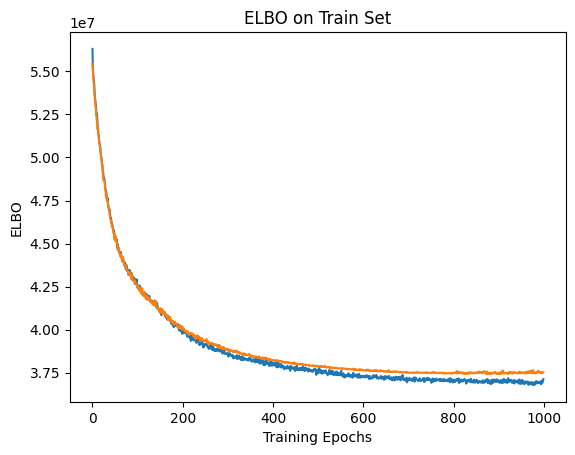

In [ ]:
plt.plot(model.history['elbo_train'])
plt.plot(model.history['elbo_val']*4)
plt.title('ELBO on Train Set')
plt.xlabel('Training Epochs')
plt.ylabel('ELBO')

In [ ]:
#This API is terrible, I really need to change it

adata_concat = mdata.uns["_flattened_ann_data"]

# Get latent representation
theta = model.get_latent_representation(adata_concat, batch_size=mdata.n_obs)

In [ ]:
mdata.obsm["X_topic"] = theta.values - 1/theta.values.shape[1]

sc.pp.neighbors(mdata, use_rep="X_topic", n_neighbors=15, metric="cosine")
sc.tl.umap(mdata, min_dist=0.3)

# 3) Get dominant topic per cell
mdata.obs["dominant_topic"] = theta.idxmax(axis=1).values

# 4) IMPORTANT: Clean up any old color information to avoid conflicts
if "dominant_topic_colors" in mdata.uns:
    del mdata.uns["dominant_topic_colors"]

# 5) Convert to categorical for better plotting
mdata.obs["dominant_topic"] = pd.Categorical(mdata.obs["dominant_topic"])

<Axes: title={'center': 'UMAP colored by Leiden Cluster'}, xlabel='X_topic1', ylabel='X_topic2'>

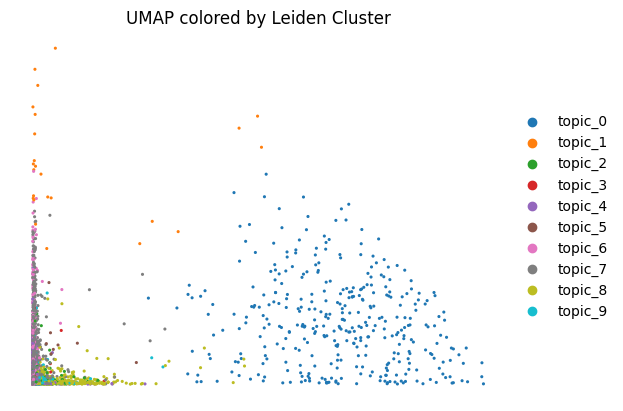

In [ ]:
mu.pl.embedding(
    mdata,
    basis = "X_topic",
    color="dominant_topic",
    frameon=False,
    s=20,
    title="UMAP colored by Leiden Cluster",
    show=False,
    legend_loc="right margin"
)

In [ ]:
print("\n" + "="*70)
print("TOPIC ABUNDANCE SUMMARY")
print("="*70)

summary_df = pd.DataFrame({
    "Mean": theta.mean(),
    "Std": theta.std(),
    "Min": theta.min(),
    "Max": theta.max(),
    "# Dominant Cells": [(theta.idxmax(axis=1) == topic).sum() for topic in theta.columns]
})

print(summary_df.round(3).to_string())


TOPIC ABUNDANCE SUMMARY
          Mean    Std  Min    Max  # Dominant Cells
topic_0  0.047  0.150  0.0  0.888               364
topic_1  0.041  0.061  0.0  0.663                24
topic_2  0.057  0.126  0.0  0.730               271
topic_3  0.051  0.071  0.0  0.585                20
topic_4  0.044  0.178  0.0  0.931               283
topic_5  0.020  0.050  0.0  0.869                 9
topic_6  0.174  0.331  0.0  0.973              1195
topic_7  0.329  0.270  0.0  0.859              2617
topic_8  0.081  0.152  0.0  0.828               445
topic_9  0.156  0.175  0.0  0.800               577
